     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

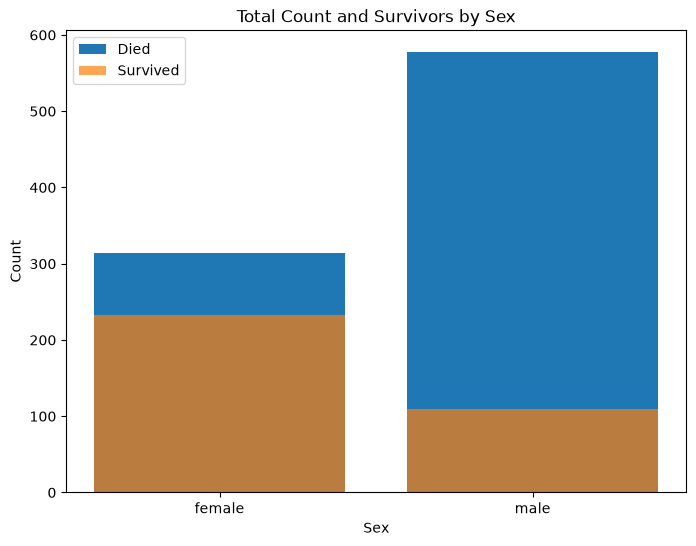

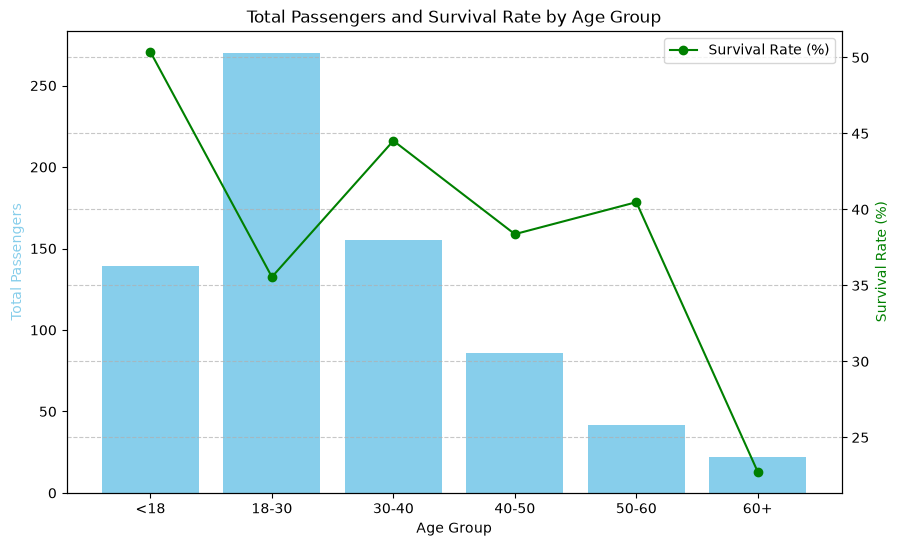

In [1]:
# -*- coding: utf-8 -*-
"""
Created on Thu Sep  7 16:04:27 2023

@author: jbrweelden
"""

import pandas as pd
import matplotlib.pyplot as plt

# Import data and view dataframe

df = pd.read_csv('Titanic.csv')
print(df)

##### Notice that three columns are relevant, being "Survived", "Sex" and "Age"
##### We first need to create some variables to be able to create proper visuals

# Group data by 'Sex' and count the total number and survivors
# This allows you plot both the total number of passengers by gender 
# and the amount of survivors (identified with "1", hence the sum)
sex_counts = df.groupby('Sex')['Survived'].agg(['count', 'sum'])

# Create a bar chart
plt.figure(figsize=(8, 6))

# Plot the bars for total counts and survivors
plt.bar(sex_counts.index, sex_counts['count'], label='Died')
plt.bar(sex_counts.index, sex_counts['sum'], label='Survived', alpha=0.7)

# Add labels and title
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Total Count and Survivors by Sex')
plt.legend()

# Show the chart
plt.show()


##### Now let's move on to the question if children are saved more often than adults. 
##### We first need to create another variable that provides age groups.

# Define age group buckets
age_bins = [0, 18, 30, 40, 50, 60, 100]  # Define age group boundaries
age_labels = ['<18', '18-30', '30-40', '40-50', '50-60', '60+']  # Labels for age groups

# Create a new column 'AgeGroup' based on age bins
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# Group data by 'AgeGroup' and calculate counts and survival rate
age_group_data = df.groupby('AgeGroup')['Survived'].agg(['count', 'sum'])
age_group_data['SurvivalRate'] = (age_group_data['sum'] / age_group_data['count']) * 100

# Create a bar chart
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the bars for total counts
ax1.bar(age_group_data.index, age_group_data['count'], color='skyblue', label='Total Passengers')

# Add labels and title for the first y-axis
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Total Passengers', color='skyblue')
ax1.set_title('Total Passengers and Survival Rate by Age Group')

# Create a second y-axis for the survival rate
ax2 = ax1.twinx()
ax2.plot(age_group_data.index, age_group_data['SurvivalRate'], marker='o', color='green', label='Survival Rate (%)')

# Add labels and title for the second y-axis
ax2.set_ylabel('Survival Rate (%)', color='green')

# Show the chart with legends
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the chart
plt.show()